# Frequency Decoding Sweep — Results Analysis

Visualise the CSV produced by `scripts/frequency_decoding_sweep.py`.

- **Section 1** – Best models comparison (STFT vs Raw vs baselines)
- **Section 2** – Single-experiment inspection (confusion matrix, classification report)
- **Section 3** – Sweep heatmaps (lowcut × highcut) per STFT mode
- **Section 4** – Line plots (best highcut vs lowcut and vice-versa)
- **Section 5** – STFT vs no-STFT comparison (side-by-side, difference, scatter)

In [23]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

In [24]:
CSV_PATH = Path("../results/sweep.csv")

df = pd.read_csv(CSV_PATH)
df.head()

,run_name,recording_id,lowcut,highcut,stft,accuracy,balanced_accuracy,f1_macro,elapsed_seconds
0,lonone_hinone_raw,sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered,NaN,NaN,False,0.350000,0.305236,0.303225,28.79
1,lo0.1_hi158.1_raw,sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered,0.100000,158.113883,False,0.325000,0.271965,0.271124,31.61
2,lo0.4729_hi15.81_raw,sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered,0.472871,15.811388,False,0.241667,0.185017,0.183803,31.79
3,lonone_hinone_stft,sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered,NaN,NaN,True,0.416667,0.354203,0.345794,32.08
4,lo2.236_hi5_stft,sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered,2.236068,5.000000,True,0.408333,0.345545,0.349853,32.42


In [25]:
METRICS = ["balanced_accuracy", "f1_macro", "accuracy"]

n_recordings = df["recording_id"].nunique() if "recording_id" in df.columns else 1
print(f"Recordings:    {n_recordings}")
if n_recordings > 1:
    print(f"  IDs: {df['recording_id'].unique().tolist()}")

GROUP_COLS = ["lowcut", "highcut", "stft"]

baseline_all = df[df["lowcut"].isna()].copy()
sweep_all = df[df["lowcut"].notna()].copy()
sweep_all["lowcut"] = sweep_all["lowcut"].astype(float)
sweep_all["highcut"] = sweep_all["highcut"].astype(float)


def _aggregate(raw_df, group_cols):
    """Group by *group_cols*, compute mean/std per metric, return a flat DataFrame."""
    agg = raw_df.groupby(group_cols)[METRICS].agg(["mean", "std"])
    out = raw_df[group_cols].drop_duplicates().reset_index(drop=True)
    agg = agg.reset_index(drop=True)
    for m in METRICS:
        out[f"{m}_mean"] = agg[(m, "mean")].values
        out[f"{m}_std"] = agg[(m, "std")].values
        out[m] = out[f"{m}_mean"]
    return out


if n_recordings > 1:
    baseline = _aggregate(baseline_all, ["stft"])
    sweep = _aggregate(sweep_all, GROUP_COLS)
else:
    baseline = baseline_all
    sweep = sweep_all

print(f"Baseline rows: {len(baseline)}")
print(f"Sweep rows:    {len(sweep)}")
print(f"STFT modes:    {sweep['stft'].unique()}")

Recordings:    6
  IDs: ['sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered', 'sub-02_ses-01_task-AcousStim_acq-LH_desc-raw', 'sub-02_ses-01_task-AcousStim_acq-RH_desc-filtered', 'sub-02_ses-01_task-AcousStim_acq-RH_desc-raw', 'sub-02_ses-02_task-AcousStim_acq-LH_desc-raw', 'sub-02_ses-02_task-AcousStim_acq-RH_desc-raw']
Baseline rows: 2
Sweep rows:    40
STFT modes:    [False  True]


## 1  Best Models Comparison

Side-by-side comparison of the best STFT model, best Raw model, and both
no-bandpass baselines.  Each bar is annotated with the optimal bandpass
filtering frequencies.

In [26]:
RANK_METRIC = "balanced_accuracy"

has_std = f"{METRICS[0]}_std" in baseline.columns

baseline_stft = baseline[baseline["stft"] == True]
baseline_raw = baseline[baseline["stft"] == False]
best_stft = sweep[sweep["stft"] == True].sort_values(RANK_METRIC, ascending=False).iloc[0]
best_raw = sweep[sweep["stft"] == False].sort_values(RANK_METRIC, ascending=False).iloc[0]

models = {}
model_stds = {}

entries = []
if not baseline_raw.empty:
    label = "Baseline\n(Raw, no BP)"
    entries.append((label, baseline_raw.iloc[0]))
if not baseline_stft.empty:
    label = "Baseline\n(STFT, no BP)"
    entries.append((label, baseline_stft.iloc[0]))
entries.append(
    (f"Best Raw\n[{best_raw['lowcut']:.2f}–{best_raw['highcut']:.1f} Hz]", best_raw)
)
entries.append(
    (f"Best STFT\n[{best_stft['lowcut']:.2f}–{best_stft['highcut']:.1f} Hz]", best_stft)
)

for label, row in entries:
    models[label] = {m: row[m] for m in METRICS}
    if has_std:
        model_stds[label] = {m: row[f"{m}_std"] for m in METRICS}


def _fmt(row, metric):
    val = row[metric]
    if has_std:
        return f"{val:.4f} ± {row[f'{metric}_std']:.4f}"
    return f"{val:.4f}"


if not baseline_raw.empty:
    print("Baseline Raw (no bandpass)")
    for m in METRICS:
        print(f"  {m}: {_fmt(baseline_raw.iloc[0], m)}")
    print()
if not baseline_stft.empty:
    print("Baseline STFT (no bandpass)")
    for m in METRICS:
        print(f"  {m}: {_fmt(baseline_stft.iloc[0], m)}")
    print()

print(f"Best Raw  — lowcut={best_raw['lowcut']:.4g} Hz, highcut={best_raw['highcut']:.4g} Hz")
for m in METRICS:
    print(f"  {m}: {_fmt(best_raw, m)}")
print()
print(f"Best STFT — lowcut={best_stft['lowcut']:.4g} Hz, highcut={best_stft['highcut']:.4g} Hz")
for m in METRICS:
    print(f"  {m}: {_fmt(best_stft, m)}")

if n_recordings > 1:
    print(f"\n(Values are means ± std over {n_recordings} recordings)")

Baseline Raw (no bandpass)
  balanced_accuracy: 0.2656 ± 0.0484
  f1_macro: 0.2607 ± 0.0547
  accuracy: 0.2936 ± 0.0710

Baseline STFT (no bandpass)
  balanced_accuracy: 0.3671 ± 0.0693
  f1_macro: 0.3462 ± 0.0594
  accuracy: 0.3996 ± 0.0907

Best Raw  — lowcut=0.1 Hz, highcut=5 Hz
  balanced_accuracy: 0.4143 ± 0.0940
  f1_macro: 0.4030 ± 0.0975
  accuracy: 0.4365 ± 0.1214

Best STFT — lowcut=50 Hz, highcut=500 Hz
  balanced_accuracy: 0.4141 ± 0.0972
  f1_macro: 0.4063 ± 0.0967
  accuracy: 0.4315 ± 0.1268

(Values are means ± std over 6 recordings)


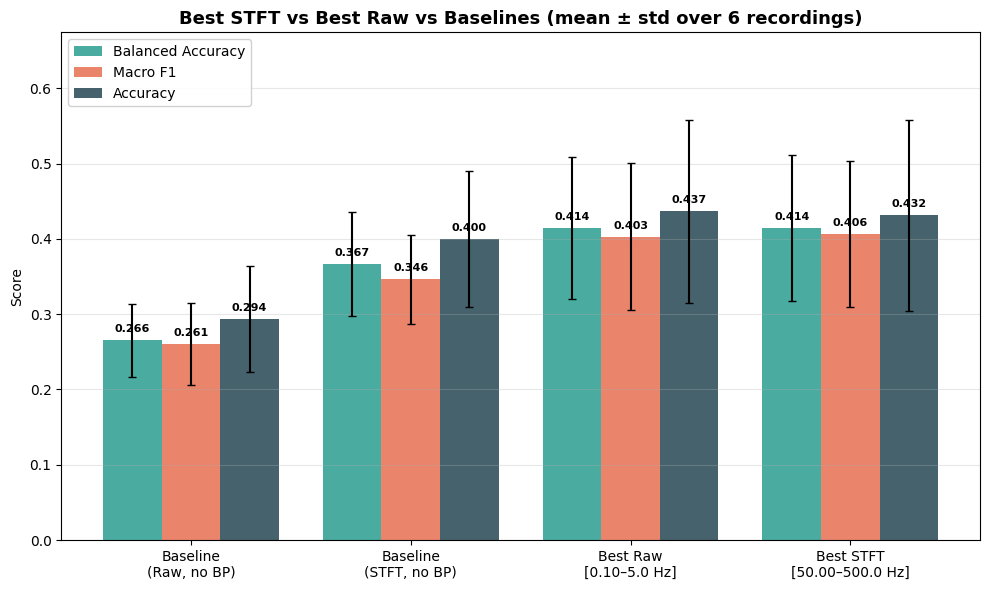

In [27]:
labels = list(models.keys())
n_models = len(labels)
n_metrics = len(METRICS)
x = np.arange(n_models)
width = 0.8 / n_metrics

METRIC_LABELS = {
    "balanced_accuracy": "Balanced Accuracy",
    "f1_macro": "Macro F1",
    "accuracy": "Accuracy",
}
METRIC_COLORS = {
    "balanced_accuracy": "#2a9d8f",
    "f1_macro": "#e76f51",
    "accuracy": "#264653",
}

fig, ax = plt.subplots(figsize=(max(10, 2.5 * n_models), 6))

for i, metric in enumerate(METRICS):
    vals = [models[l][metric] for l in labels]
    errs = [model_stds.get(l, {}).get(metric, 0.0) for l in labels] if model_stds else None
    bars = ax.bar(
        x + i * width - (n_metrics - 1) * width / 2,
        vals,
        width,
        yerr=errs if errs and any(e > 0 for e in errs) else None,
        capsize=3,
        label=METRIC_LABELS.get(metric, metric),
        color=METRIC_COLORS.get(metric, None),
        alpha=0.85,
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{v:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Score")
title = "Best STFT vs Best Raw vs Baselines"
if n_recordings > 1:
    title += f" (mean ± std over {n_recordings} recordings)"
ax.set_title(title, fontsize=13, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)
ax.set_ylim(0, min(1.0, ax.get_ylim()[1] * 1.15))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2  Single-Experiment Inspection

Pick the best run (by balanced accuracy) and re-run it to get the full
classification report and confusion matrix.  Skip this section if you only
want the sweep overview.

In [28]:
from auditorydecoding.experiments.frequency_decoding_pipeline import (
    FrequencyDecodingConfig,
    run_experiment,
    load_recording,
    bandpass_filter,
    _fit_pca_and_transform,
    _apply_bandpass,
    _resolve_splits,
    _extract_features,
)
from auditorydecoding.windowing import extract_windows
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

best_row = sweep.loc[sweep["balanced_accuracy"].idxmax()]
print("Best run (by balanced accuracy):")
print(best_row)

Best run (by balanced accuracy):
lowcut                         0.1
highcut                        5.0
stft                         False
balanced_accuracy_mean     0.41431
balanced_accuracy_std     0.094036
balanced_accuracy          0.41431
f1_macro_mean             0.403047
f1_macro_std              0.097475
f1_macro                  0.403047
accuracy_mean             0.436509
accuracy_std              0.121383
accuracy                  0.436509
Name: 39, dtype: object


In [29]:
cfg = FrequencyDecodingConfig(
    bandpass_lowcut=best_row["lowcut"],
    bandpass_highcut=best_row["highcut"],
    stft=bool(best_row["stft"]),
)

data = load_recording(cfg.data_root, cfg.recording_id)
keep = data.channels.type == "ecog"
signal = data.ecog.signal[:, keep]
timestamps = np.asarray(data.ecog.timestamps)
train_iv, valid_iv = _resolve_splits(data, cfg.task_type)

train_chunks = [
    data.slice(float(iv[0]), float(iv[1])).ecog.signal[:, keep]
    for iv in train_iv.coalesce()
]
data_train_raw = np.concatenate(train_chunks, axis=0)

signal = _apply_bandpass(signal, cfg)
data_train_filtered = _apply_bandpass(data_train_raw, cfg)
signal = _fit_pca_and_transform(signal, data_train_filtered, cfg)

X_train_w, y_train = extract_windows(signal, timestamps, train_iv, cfg.window_length)
X_valid_w, y_valid = extract_windows(signal, timestamps, valid_iv, cfg.window_length)

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_valid_enc = le.transform(y_valid)

X_train = _extract_features(X_train_w, cfg)
X_valid = _extract_features(X_valid_w, cfg)

clf = LogisticRegression(max_iter=cfg.logreg_max_iter)
clf.fit(X_train, y_train_enc)
y_pred = clf.predict(X_valid)

print(classification_report(y_valid_enc, y_pred, target_names=le.classes_))

Extracting windows: 100%|██████████| 120/120 [00:01<00:00, 78.87it/s]


KeyboardInterrupt: 

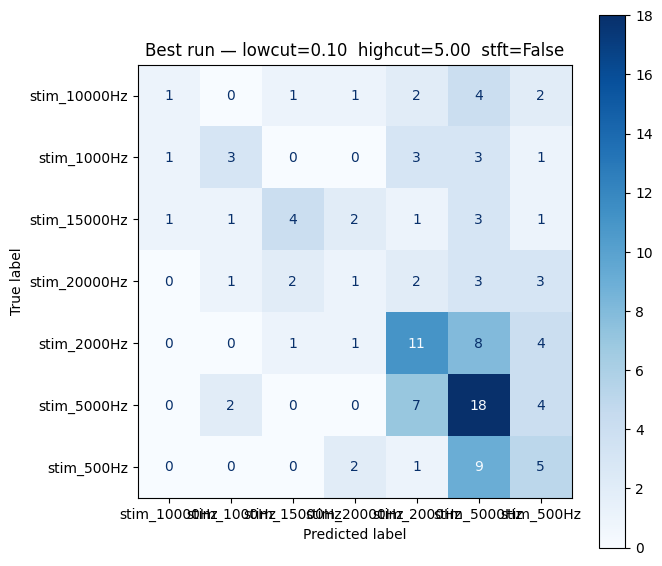

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_valid_enc, y_pred,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax,
)
ax.set_title(
    f"Best run — lowcut={best_row['lowcut']:.2f}  "
    f"highcut={best_row['highcut']:.2f}  "
    f"stft={best_row['stft']}"
)
plt.tight_layout()
plt.show()

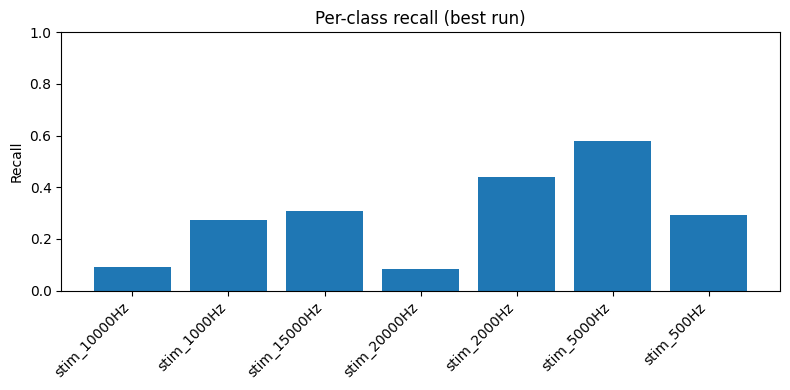

In [31]:
recalls = []
for c in range(len(le.classes_)):
    mask = y_valid_enc == c
    recalls.append((y_pred[mask] == c).mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(le.classes_, recalls)
ax.set_ylabel("Recall")
ax.set_title("Per-class recall (best run)")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3  Sweep Heatmaps

One heatmap per (metric, STFT mode).  Axes are log-scaled to match the
geomspace sweep grid.

In [32]:
def plot_heatmap(df_mode, metric, ax, title, vmin=None, vmax=None, cmap="viridis"):
    pivot = df_mode.pivot_table(
        index="lowcut", columns="highcut", values=metric, aggfunc="mean"
    )
    lowcuts = pivot.index.values
    highcuts = pivot.columns.values

    im = ax.pcolormesh(
        highcuts, lowcuts, pivot.values,
        shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("highcut (Hz)")
    ax.set_ylabel("lowcut (Hz)")
    ax.set_title(title)
    return im

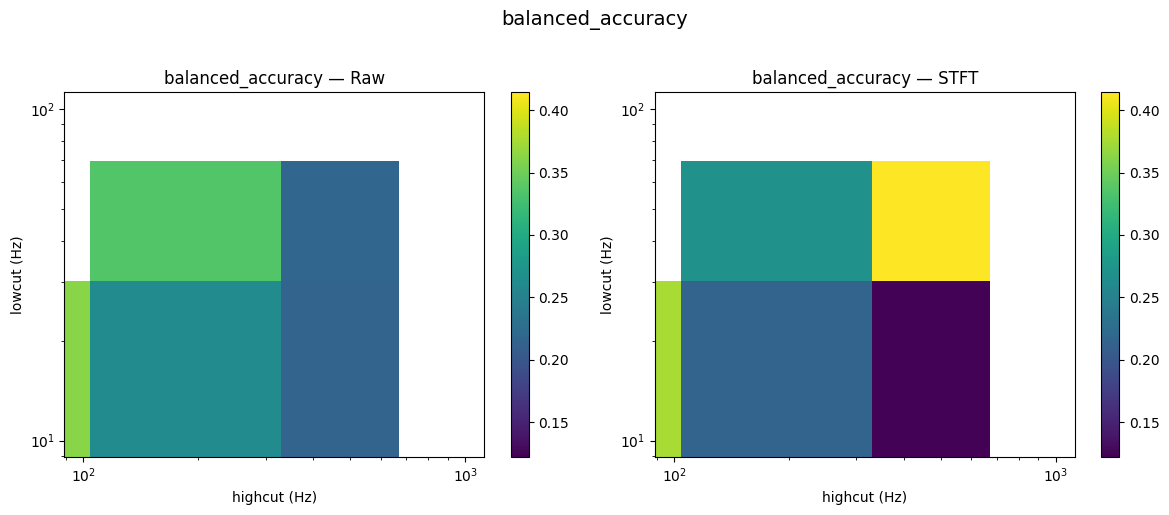

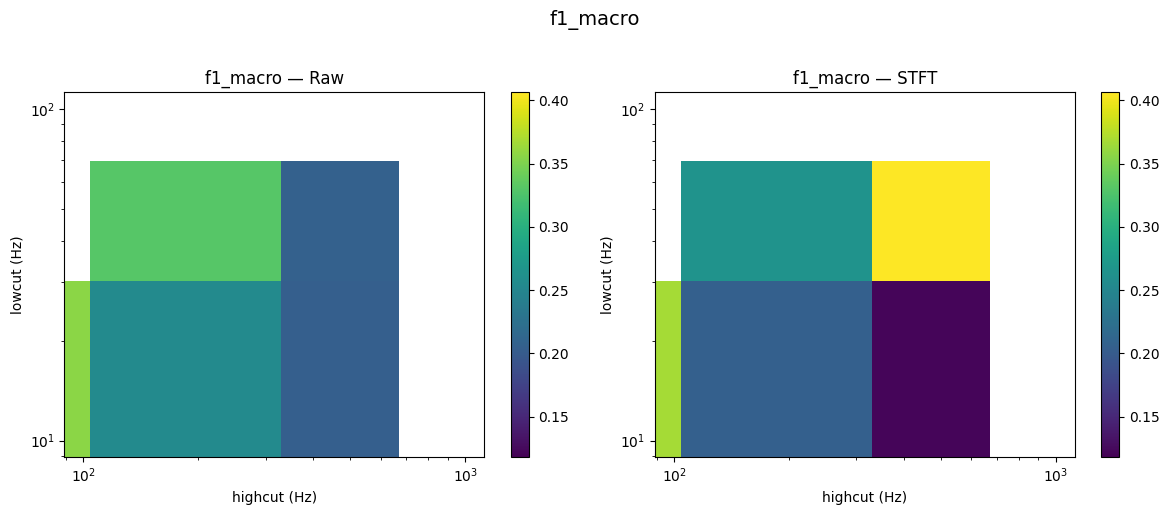

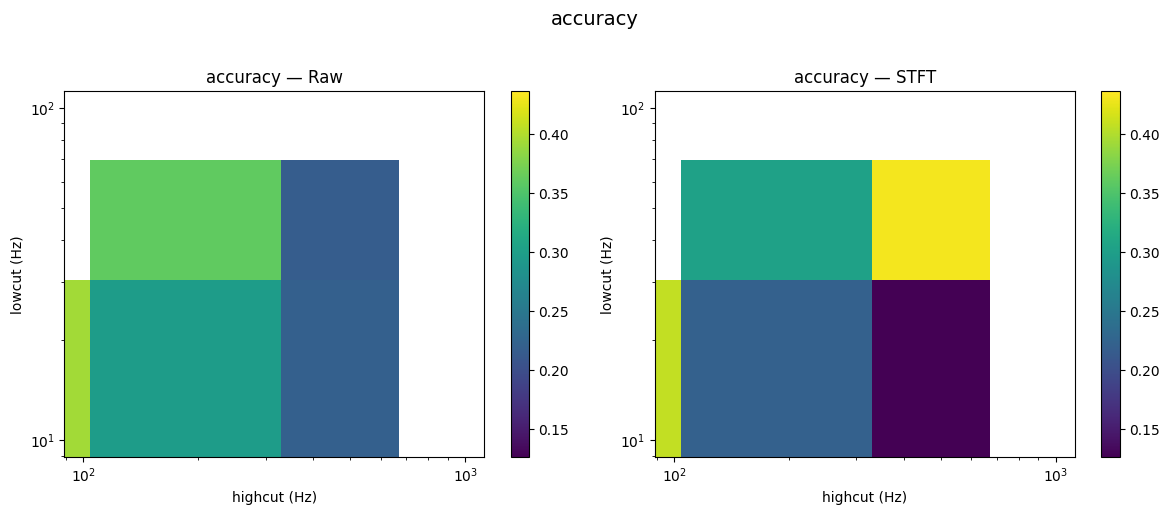

In [33]:
stft_modes = sorted(sweep["stft"].unique())

for metric in METRICS:
    fig, axes = plt.subplots(
        1, len(stft_modes),
        figsize=(6 * len(stft_modes), 5),
        squeeze=False,
    )
    vmin = sweep[metric].min()
    vmax = sweep[metric].max()

    for j, stft_val in enumerate(stft_modes):
        ax = axes[0, j]
        df_mode = sweep[sweep["stft"] == stft_val]
        tag = "STFT" if stft_val else "Raw"
        im = plot_heatmap(
            df_mode, metric, ax,
            title=f"{metric} — {tag}",
            vmin=vmin, vmax=vmax,
        )
        fig.colorbar(im, ax=ax)

    fig.suptitle(metric, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 4  Line Plots — Best Frequencies

For each metric: best highcut as a function of lowcut, and best lowcut
as a function of highcut.

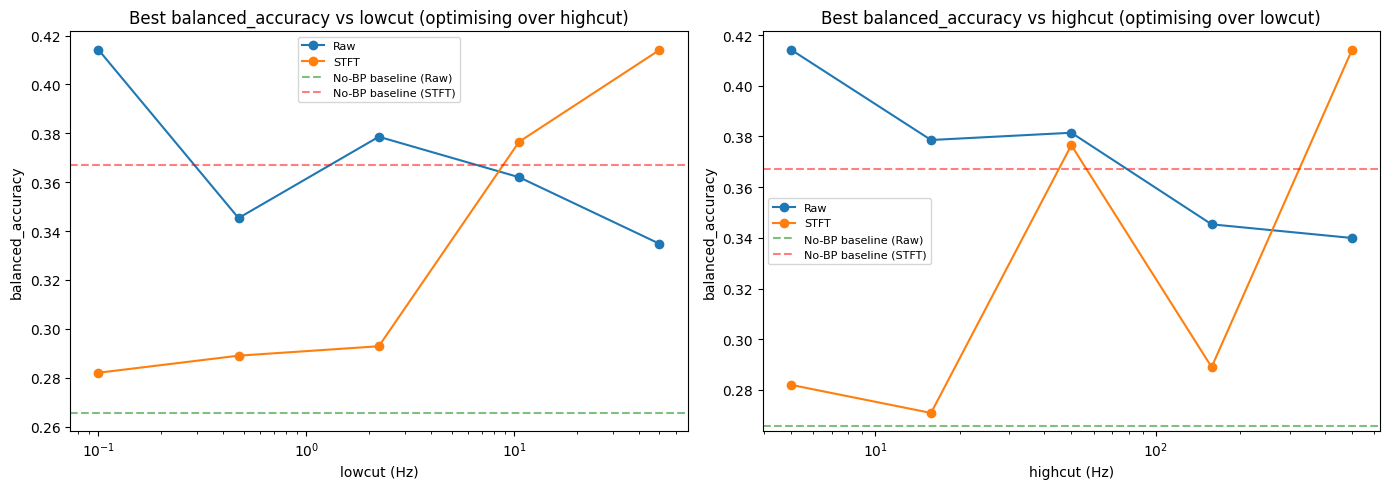

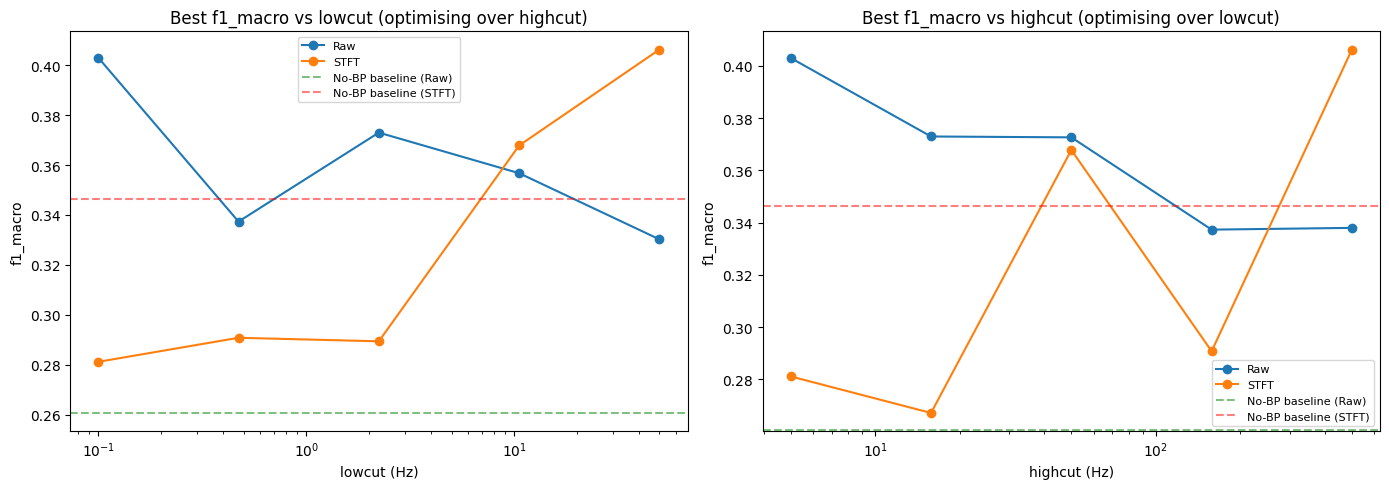

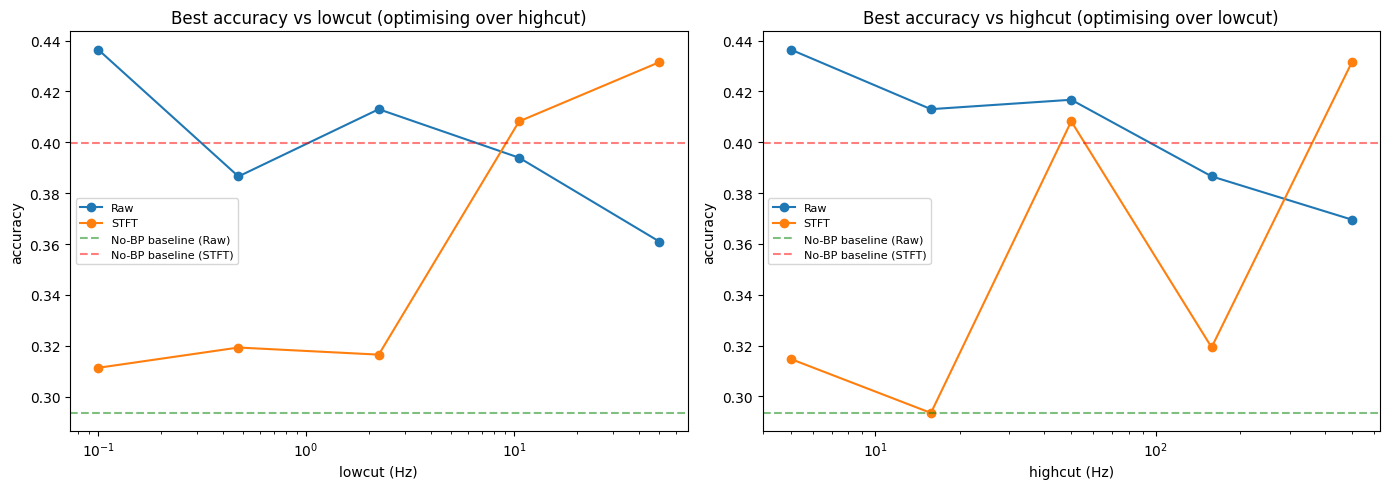

In [34]:
for metric in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for stft_val in stft_modes:
        df_m = sweep[sweep["stft"] == stft_val]
        tag = "STFT" if stft_val else "Raw"

        best_hi = df_m.loc[df_m.groupby("lowcut")[metric].idxmax()]
        axes[0].semilogx(
            best_hi["lowcut"], best_hi[metric],
            marker="o", label=f"{tag}",
        )

        best_lo = df_m.loc[df_m.groupby("highcut")[metric].idxmax()]
        axes[1].semilogx(
            best_lo["highcut"], best_lo[metric],
            marker="o", label=f"{tag}",
        )

    for stft_val in stft_modes:
        bl = baseline[baseline["stft"] == stft_val]
        if not bl.empty:
            tag = "STFT" if stft_val else "Raw"
            axes[0].axhline(
                bl[metric].values[0], ls="--", color="r" if stft_val else "g", alpha=0.5,
                label=f"No-BP baseline ({tag})",
            )
            axes[1].axhline(
                bl[metric].values[0], ls="--", color="r" if stft_val else "g", alpha=0.5,
                label=f"No-BP baseline ({tag})",
            )

    axes[0].set_xlabel("lowcut (Hz)")
    axes[0].set_ylabel(metric)
    axes[0].set_title(f"Best {metric} vs lowcut (optimising over highcut)")
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel("highcut (Hz)")
    axes[1].set_ylabel(metric)
    axes[1].set_title(f"Best {metric} vs highcut (optimising over lowcut)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 5  STFT vs No-STFT Comparison

In [35]:
sweep_stft = sweep[sweep["stft"] == True].set_index(["lowcut", "highcut"])
sweep_raw  = sweep[sweep["stft"] == False].set_index(["lowcut", "highcut"])
common_idx = sweep_stft.index.intersection(sweep_raw.index)

print(f"Common (lowcut, highcut) pairs: {len(common_idx)}")

Common (lowcut, highcut) pairs: 20


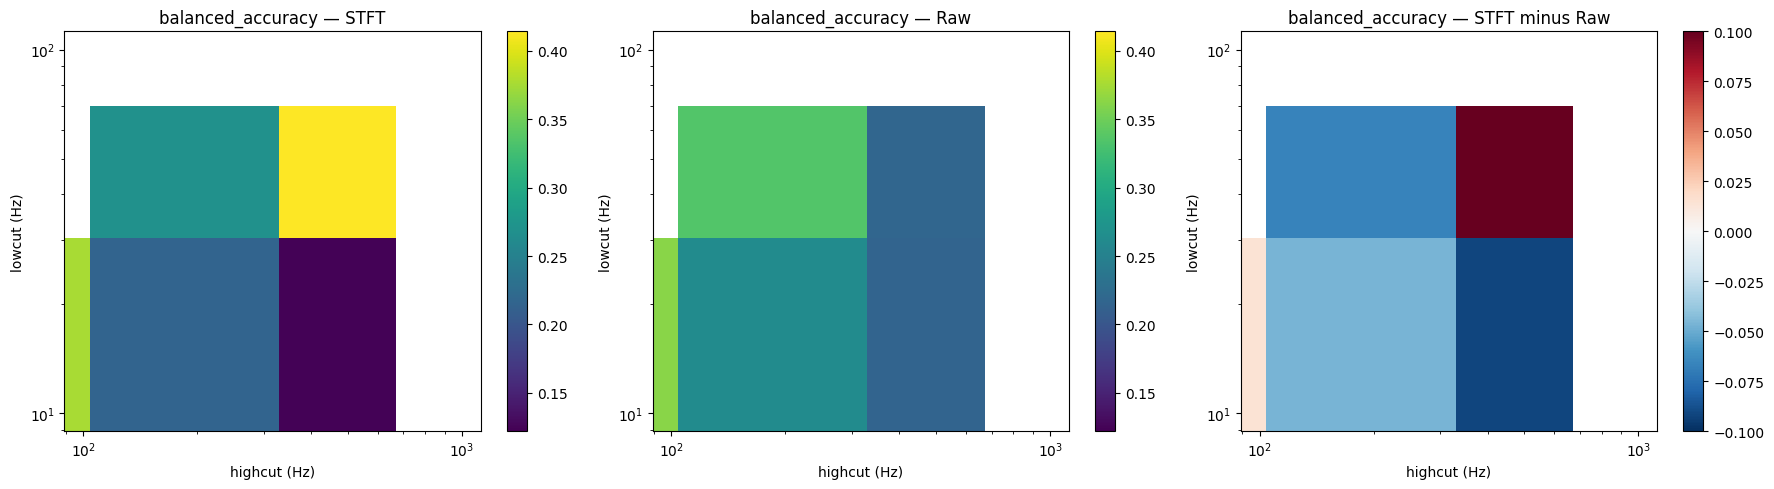

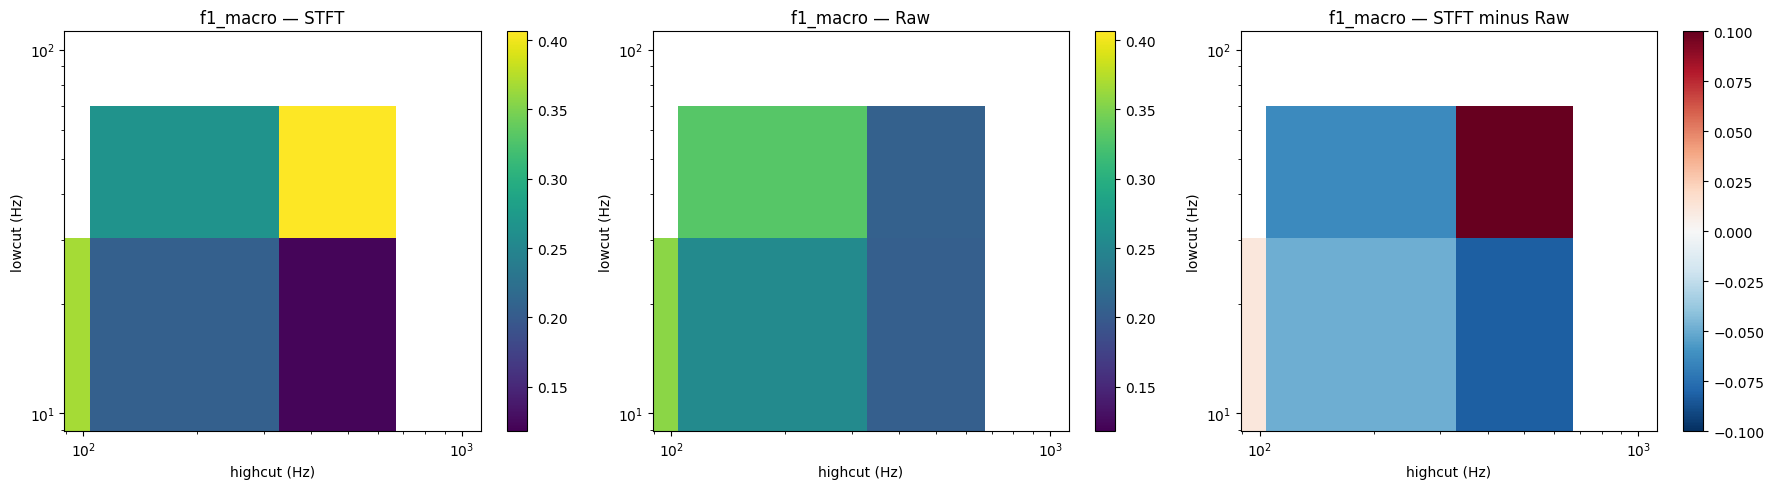

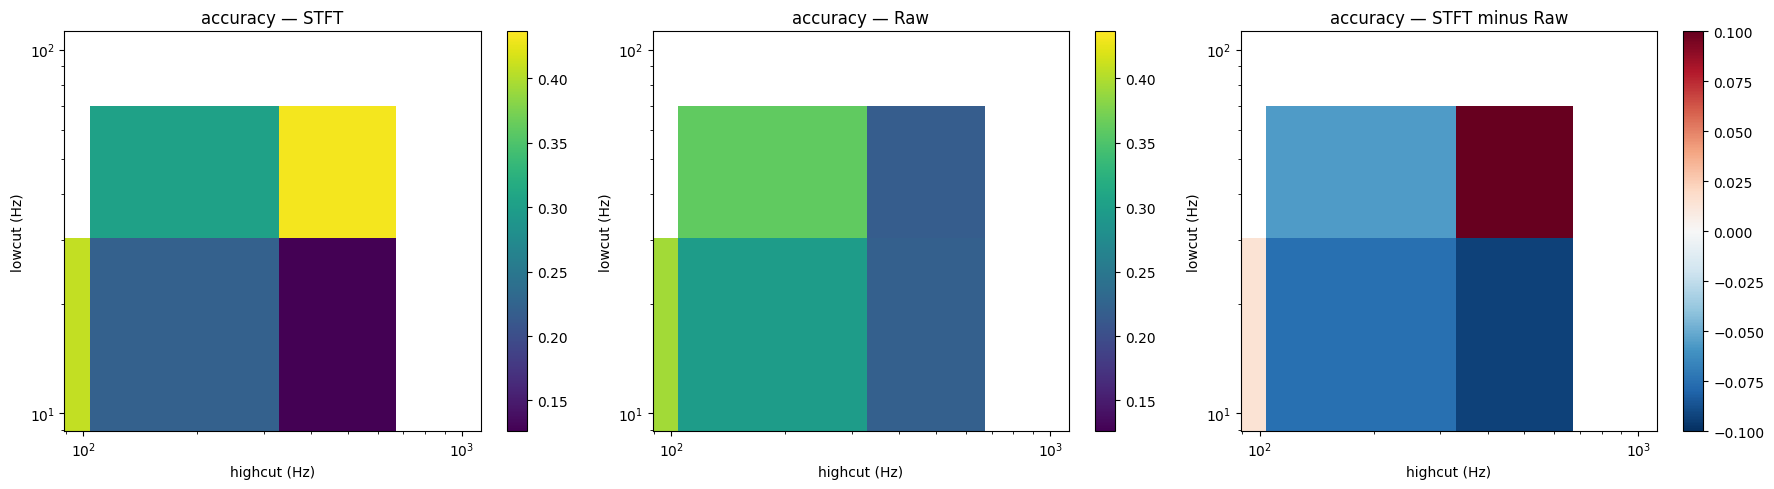

In [36]:
for metric in METRICS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    stft_vals = sweep_stft.loc[common_idx, metric].reset_index()
    raw_vals = sweep_raw.loc[common_idx, metric].reset_index()

    # --- Side-by-side heatmaps ---
    vmin = min(stft_vals[metric].min(), raw_vals[metric].min())
    vmax = max(stft_vals[metric].max(), raw_vals[metric].max())

    for ax, vals, tag in [
        (axes[0], stft_vals, "STFT"),
        (axes[1], raw_vals, "Raw"),
    ]:
        pivot = vals.pivot_table(
            index="lowcut", columns="highcut", values=metric,
        )
        im = ax.pcolormesh(
            pivot.columns.values, pivot.index.values, pivot.values,
            shading="nearest", cmap="viridis", vmin=vmin, vmax=vmax,
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("highcut (Hz)")
        ax.set_ylabel("lowcut (Hz)")
        ax.set_title(f"{metric} — {tag}")
        fig.colorbar(im, ax=ax)

    # --- Difference heatmap ---
    diff = stft_vals.copy()
    diff[metric] = stft_vals[metric].values - raw_vals[metric].values
    pivot_d = diff.pivot_table(
        index="lowcut", columns="highcut", values=metric,
    )
    abs_max = max(abs(pivot_d.values.min()), abs(pivot_d.values.max()), 1e-6)
    im = axes[2].pcolormesh(
        pivot_d.columns.values, pivot_d.index.values, pivot_d.values,
        shading="nearest", cmap="RdBu_r", vmin=-abs_max, vmax=abs_max,
    )
    axes[2].set_xscale("log")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("highcut (Hz)")
    axes[2].set_ylabel("lowcut (Hz)")
    axes[2].set_title(f"{metric} — STFT minus Raw")
    fig.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

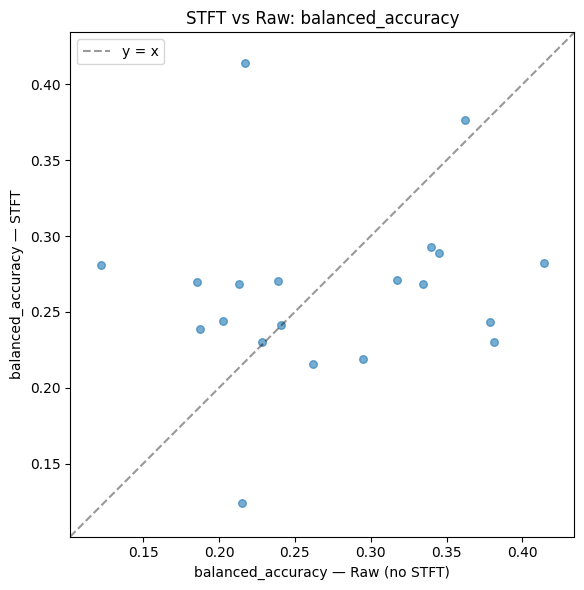

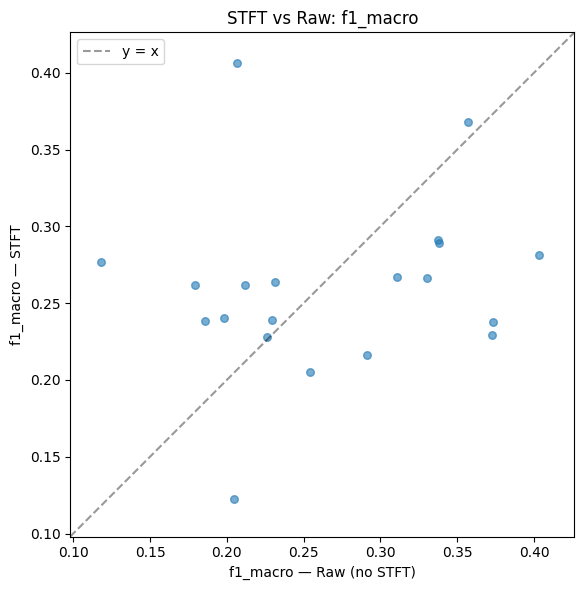

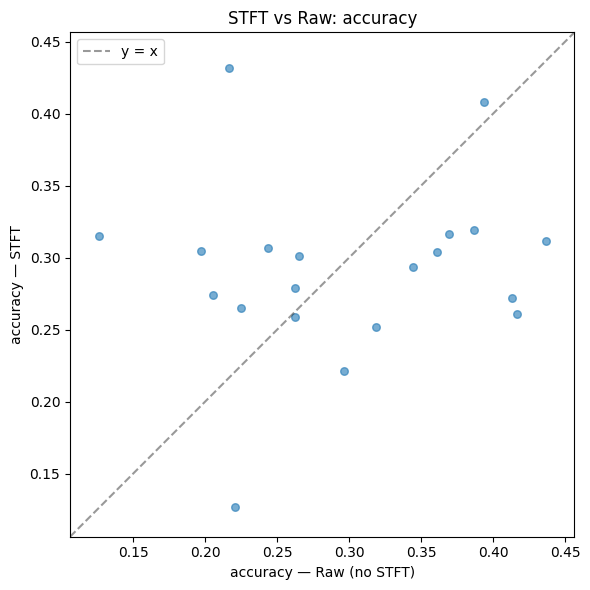

In [37]:
for metric in METRICS:
    stft_v = sweep_stft.loc[common_idx, metric].values
    raw_v = sweep_raw.loc[common_idx, metric].values

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(raw_v, stft_v, alpha=0.6, s=30)
    lims = [
        min(raw_v.min(), stft_v.min()) - 0.02,
        max(raw_v.max(), stft_v.max()) + 0.02,
    ]
    ax.plot(lims, lims, "k--", alpha=0.4, label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f"{metric} — Raw (no STFT)")
    ax.set_ylabel(f"{metric} — STFT")
    ax.set_title(f"STFT vs Raw: {metric}")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()